<a href="https://colab.research.google.com/github/momensaleh193-png/NTI-ML-/blob/main/gas_sensor_eda_cleaning_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('gas_sensor_array_drift_dataset.csv')
print("number of rows and columns  :", df.shape)
df.head()

number of rows and columns  : (13910, 131)


,batch,gas_id,gas_name,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128
0,1,1,Ethanol,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,...,-1.071137,-3.037772,3037.0390,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529
1,1,1,Ethanol,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,...,-1.530519,-1.994993,4176.4453,4.281373,0.980205,1.628050,1.951172,-0.889333,-1.323505,-1.749225
2,1,1,Ethanol,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,...,-2.384784,-2.867291,5914.6685,5.396827,1.403973,2.476956,3.039841,-1.334558,-1.993659,-2.348370
3,1,1,Ethanol,42825.9883,3.451192,12.113940,16.266853,39.910056,-7.849409,-9.689894,...,-2.607199,-3.058086,6147.4744,5.501071,1.981933,3.569823,4.049197,-1.432205,-2.146158,-2.488957
4,1,1,Ethanol,58151.1757,4.194839,11.455096,15.715298,17.654915,-11.083364,-13.580692,...,-3.594763,-4.181920,8158.6449,7.174334,1.993808,3.829303,4.402448,-1.930107,-2.931265,-4.088756


In [36]:
"""
!pip install -q ydata-profiling

from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Gas Sensor Array Drift - تقرير شامل", explorative=True, minimal=True)


profile.to_notebook_iframe()
"""

'\n!pip install -q ydata-profiling\n\nfrom ydata_profiling import ProfileReport\n\nprofile = ProfileReport(df, title="Gas Sensor Array Drift - تقرير شامل", explorative=True, minimal=True)\n\n\nprofile.to_notebook_iframe()\n'

In [37]:
feature_cols = [c for c in df.columns if c.startswith('feature_')]
print(" number of columns:", len(feature_cols))


 number of columns: 128


In [38]:
from sklearn.impute import SimpleImputer

missing = df[feature_cols].isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print("no missing values  ")
else:
    print(" missing values are :")
    print(missing)
    imputer = SimpleImputer(strategy='median')
    df[feature_cols] = imputer.fit_transform(df[feature_cols])



no missing values  


In [39]:
n_duplicates = df.duplicated().sum()
print("  duplicated rows :", n_duplicates)



  duplicated rows : 0


In [40]:
print(df.dtypes.value_counts())

for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

new_missing = df[feature_cols].isnull().sum().sum()
print("new missing values  :", new_missing)



float64    128
int64        2
object       1
Name: count, dtype: int64
new missing values  : 0


In [41]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.02, random_state=42)
outlier_flags = iso.fit_predict(df[feature_cols])

df['is_outlier'] = outlier_flags  # -1 = شاذ, 1 = عادي
n_outliers = (df['is_outlier'] == -1).sum()
print("  outlier rows  :", n_outliers)


  outlier rows  : 279


/tmp/ipykernel_2619/1503475734.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['is_outlier'] = outlier_flags  # -1 = شاذ, 1 = عادي


In [42]:
for c in feature_cols:
    lower = df[c].quantile(0.01)
    upper = df[c].quantile(0.99)
    df[c] = df[c].clip(lower=lower, upper=upper)

df = df.drop(columns=['is_outlier'])


In [43]:
scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])


print(df_scaled[feature_cols].mean().round(3).head())
print(df_scaled[feature_cols].std().round(3).head())


feature_1   -0.0
feature_2    0.0
feature_3    0.0
feature_4   -0.0
feature_5    0.0
dtype: float64
feature_1    1.0
feature_2    1.0
feature_3    1.0
feature_4    1.0
feature_5    1.0
dtype: float64


In [44]:
print("  gas distribution:")
print(df['gas_name'].value_counts())

print("\n  batches:")
print(df['batch'].value_counts().sort_index())


  gas distribution:
gas_name
Acetone         3009
Ethylene        2926
Ethanol         2565
Acetaldehyde    1936
Toluene         1833
Ammonia         1641
Name: count, dtype: int64

  batches:
batch
1      445
2     1244
3     1586
4      161
5      197
6     2300
7     3613
8      294
9      470
10    3600
Name: count, dtype: int64


In [45]:
df.to_csv('gas_sensor_cleaned.csv', index=False)
df_scaled.to_csv('gas_sensor_cleaned_scaled.csv', index=False)




In [46]:
import matplotlib.pyplot as plt
import seaborn as sns


print(" number of rows and columns:", df.shape)
df.head()


 number of rows and columns: (13910, 131)


,batch,gas_id,gas_name,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128
0,1,1,Ethanol,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,...,-1.071137,-3.037772,3037.0390,3.972203,0.527291,0.848363,2.782893,-0.545079,-0.902241,-2.654529
1,1,1,Ethanol,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,...,-1.530519,-2.889309,4176.4453,4.281373,0.980205,1.628050,2.782893,-0.889333,-1.323505,-2.620467
2,1,1,Ethanol,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,...,-2.384784,-2.889309,5914.6685,5.396827,1.403973,2.476956,3.039841,-1.334558,-1.993659,-2.620467
3,1,1,Ethanol,42825.9883,3.451192,12.113940,16.266853,39.910056,-7.849409,-9.689894,...,-2.607199,-3.058086,6147.4744,5.501071,1.981933,3.569823,4.049197,-1.432205,-2.146158,-2.620467
4,1,1,Ethanol,58151.1757,4.194839,11.455096,15.715298,17.654915,-11.083364,-13.580692,...,-3.594763,-4.181920,8158.6449,7.174334,1.993808,3.829303,4.402448,-1.930107,-2.931265,-4.088756


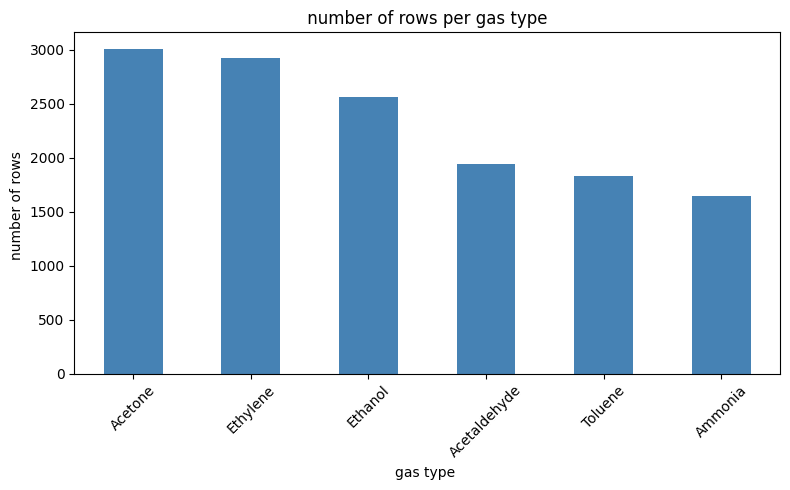

In [47]:
plt.figure(figsize=(8,5))
df['gas_name'].value_counts().plot(kind='bar', color='steelblue')
plt.title(' number of rows per gas type ')
plt.xlabel('gas type ')
plt.ylabel('number of rows ')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


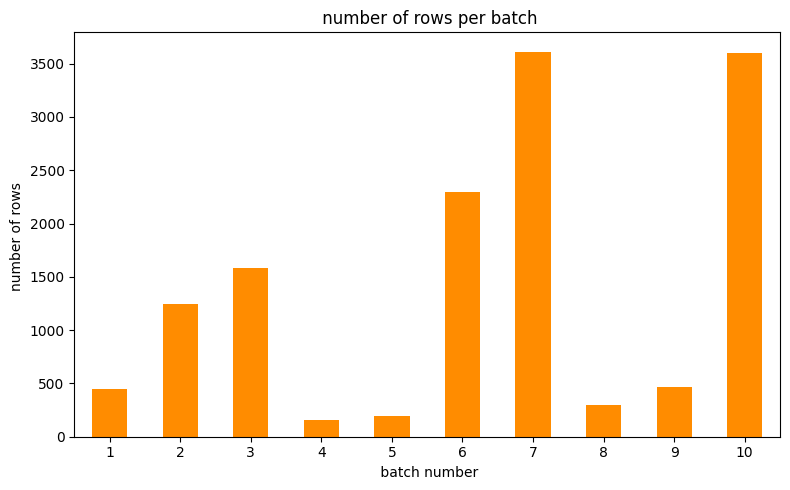

In [48]:
plt.figure(figsize=(8,5))
df['batch'].value_counts().sort_index().plot(kind='bar', color='darkorange')
plt.title(' number of rows per batch')
plt.xlabel(' batch number')
plt.ylabel('number of rows ')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


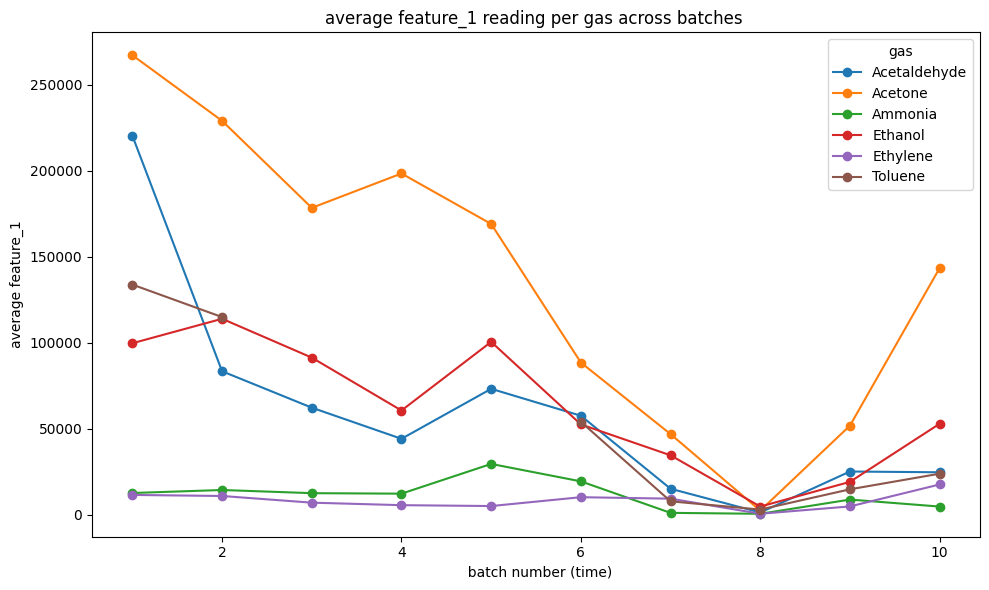

In [49]:
drift_view = df.groupby(['batch', 'gas_name'])['feature_1'].mean().unstack()

plt.figure(figsize=(10,6))
for gas in drift_view.columns:
    plt.plot(drift_view.index, drift_view[gas], marker='o', label=gas)

plt.title("average feature_1 reading per gas across batches ")
plt.xlabel('  batch number (time)')
plt.ylabel('average feature_1')
plt.legend(title='gas')
plt.tight_layout()
plt.show()


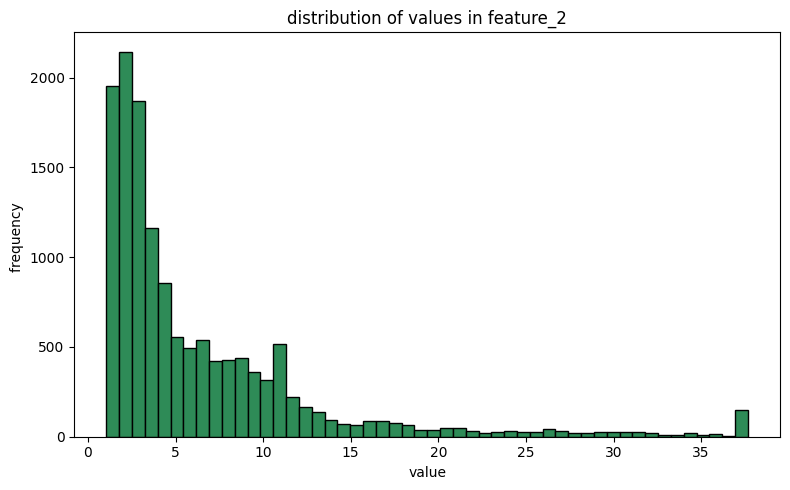

In [50]:
plt.figure(figsize=(8,5))
plt.hist(df['feature_2'], bins=50, color='seagreen', edgecolor='black')
plt.title("distribution of values in feature_2")
plt.xlabel('value')
plt.ylabel('frequency ')
plt.tight_layout()
plt.show()


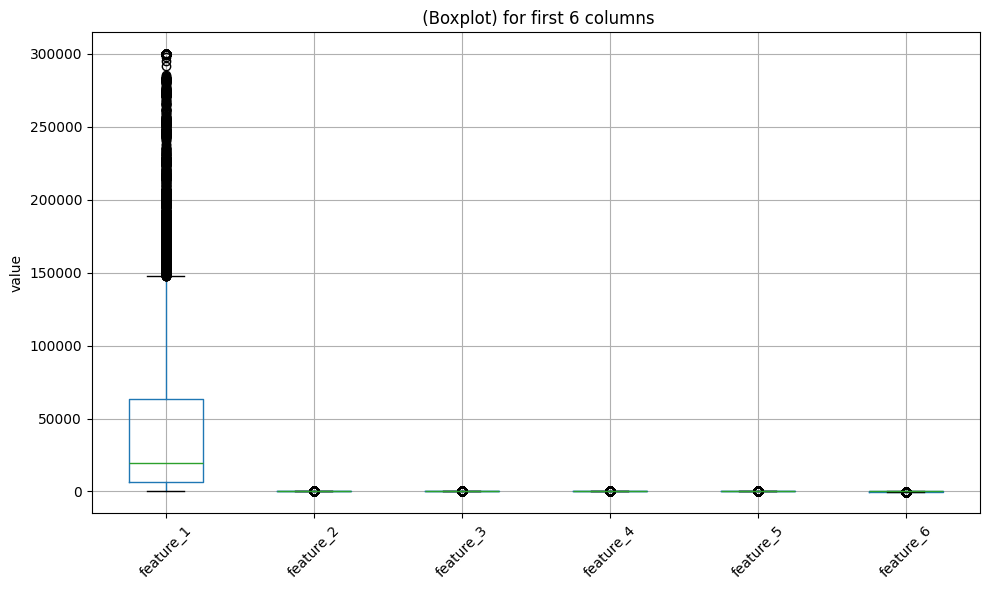

In [51]:
plt.figure(figsize=(10,6))
df[feature_cols[:6]].boxplot()
plt.title(' (Boxplot) for first 6 columns')
plt.ylabel('value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


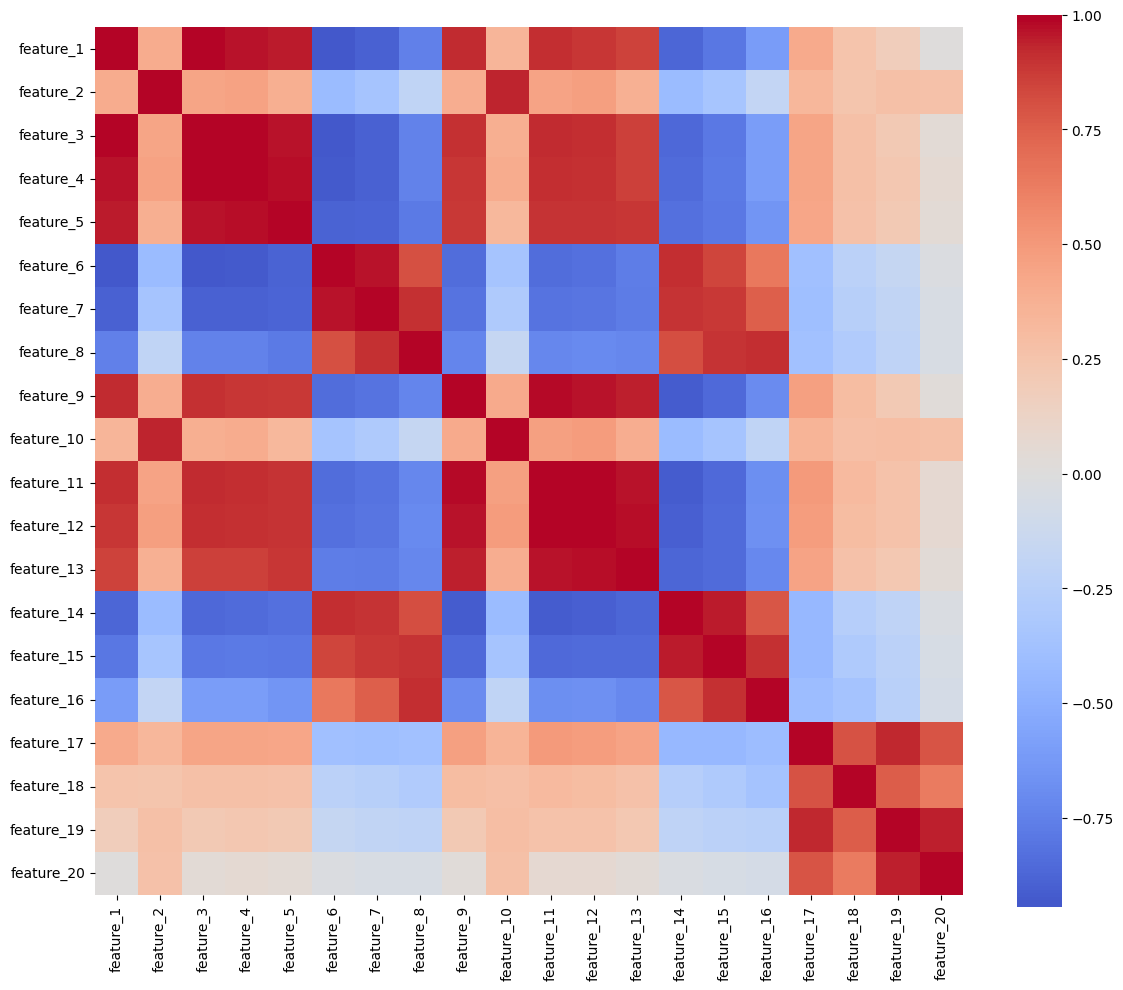

In [52]:
plt.figure(figsize=(12,10))
corr = df[feature_cols[:20]].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, square=True)
plt.tight_layout()
plt.show()


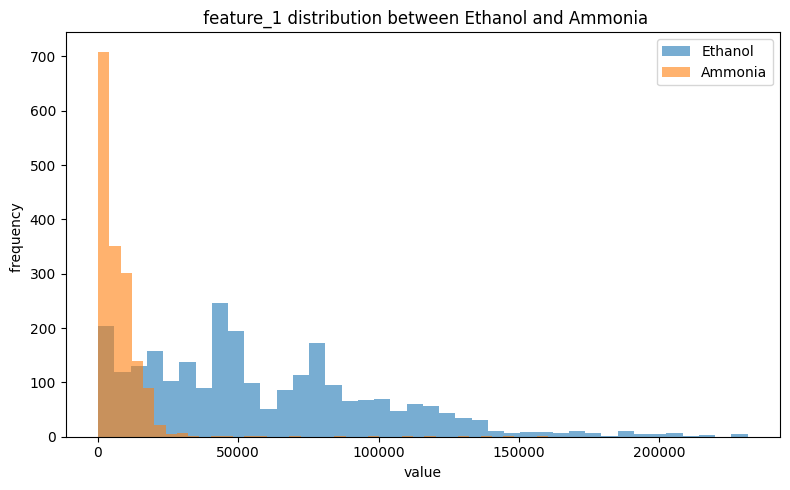

In [53]:
plt.figure(figsize=(8,5))
for gas in ['Ethanol', 'Ammonia']:
    subset = df[df['gas_name'] == gas]['feature_1']
    plt.hist(subset, bins=40, alpha=0.6, label=gas)

plt.title(' feature_1 distribution between Ethanol and Ammonia')
plt.xlabel('value')
plt.ylabel('frequency ')
plt.legend()
plt.tight_layout()
plt.show()


In [54]:
from sklearn.preprocessing import StandardScaler


train_data = df[df['batch'].isin( [1,2,3,4,5,6])]
test_data = df[~df['batch'].isin( [1,2,3,4,5,6])]

X_train = train_data[feature_cols]
y_train = train_data['gas_name']

X_test = test_data[feature_cols]
y_test = test_data['gas_name']

print("عدد صفوف التدريب:", X_train.shape[0])
print("عدد صفوف الاختبار:", X_test.shape[0])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

عدد صفوف التدريب: 5933
عدد صفوف الاختبار: 7977


In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

Acetaldehyde       0.99      0.09      0.16      1452
     Acetone       0.89      0.88      0.89      1451
     Ammonia       0.75      0.67      0.71      1100
     Ethanol       0.66      0.96      0.78      1340
    Ethylene       0.56      0.93      0.70      1347
     Toluene       0.78      0.73      0.75      1287

    accuracy                           0.71      7977
   macro avg       0.77      0.71      0.66      7977
weighted avg       0.78      0.71      0.66      7977



In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

C_values = [0.001, 0.01, 0.1, 1, 10, 100]

print("=== تجربة قيم C مختلفة في Logistic Regression ===")
for c in C_values:
    model = LogisticRegression(C=c, max_iter=1000, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"C = {c:<8} -> Accuracy = {acc:.4f}")

=== تجربة قيم C مختلفة في Logistic Regression ===
C = 0.001    -> Accuracy = 0.6746
C = 0.01     -> Accuracy = 0.7093
C = 0.1      -> Accuracy = 0.7019
C = 1        -> Accuracy = 0.7063
C = 10       -> Accuracy = 0.6863
C = 100      -> Accuracy = 0.6637


In [57]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("=== KNN ===")
print(classification_report(y_test, y_pred_knn))

=== KNN ===
              precision    recall  f1-score   support

Acetaldehyde       0.39      0.13      0.20      1452
     Acetone       0.62      0.85      0.72      1451
     Ammonia       0.98      0.57      0.72      1100
     Ethanol       0.71      0.67      0.69      1340
    Ethylene       0.72      0.79      0.76      1347
     Toluene       0.43      0.71      0.53      1287

    accuracy                           0.62      7977
   macro avg       0.64      0.62      0.60      7977
weighted avg       0.63      0.62      0.60      7977



In [58]:
from sklearn.neighbors import KNeighborsClassifier

K_values = [1, 3, 5, 7, 9, 11, 15, 21]

print("=== تجربة قيم K مختلفة في KNN ===")
for k in K_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"K = {k:<3} -> Accuracy = {acc:.4f}")

=== تجربة قيم K مختلفة في KNN ===
K = 1   -> Accuracy = 0.6262
K = 3   -> Accuracy = 0.6240
K = 5   -> Accuracy = 0.6173
K = 7   -> Accuracy = 0.6126
K = 9   -> Accuracy = 0.6089
K = 11  -> Accuracy = 0.6080
K = 15  -> Accuracy = 0.6055
K = 21  -> Accuracy = 0.6005


In [59]:
from sklearn.svm import SVC

C_values_svm = [0.01, 0.1, 1, 10, 100]

print("=== تجربة قيم C مختلفة في SVM ===")
for c in C_values_svm:
    model = SVC(C=c, kernel='rbf', random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"C = {c:<6} -> Accuracy = {acc:.4f}")


=== تجربة قيم C مختلفة في SVM ===
C = 0.01   -> Accuracy = 0.4284
C = 0.1    -> Accuracy = 0.6393
C = 1      -> Accuracy = 0.7288
C = 10     -> Accuracy = 0.7349
C = 100    -> Accuracy = 0.7174


In [60]:
from sklearn.tree import DecisionTreeClassifier

depth_values = [3, 5, 8, 10, 15, 20, None]

print("=== تجربة قيم max_depth مختلفة في Decision Tree ===")
for d in depth_values:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"max_depth = {str(d):<6} -> Accuracy = {acc:.4f}")

=== تجربة قيم max_depth مختلفة في Decision Tree ===
max_depth = 3      -> Accuracy = 0.4355
max_depth = 5      -> Accuracy = 0.4952
max_depth = 8      -> Accuracy = 0.5210
max_depth = 10     -> Accuracy = 0.5320
max_depth = 15     -> Accuracy = 0.5324
max_depth = 20     -> Accuracy = 0.5324
max_depth = None   -> Accuracy = 0.5324


In [61]:
def scale_per_batch(df, feature_cols):
    """
    توحيد كل batch لوحده بدل توحيد الداتا كلها مرة واحدة.
    ده بيقلل تأثير الـ Drift لأن كل batch بيتوحد حسب متوسطه هو بس.
    """
    df_scaled = df.copy()
    for b in df['batch'].unique():
        mask = df['batch'] == b
        scaler = StandardScaler()
        df_scaled.loc[mask, feature_cols] = scaler.fit_transform(df.loc[mask, feature_cols])
    return df_scaled

# تطبيق التوحيد لكل batch لوحده على الداتا كلها
df_domain_adapted = scale_per_batch(df, feature_cols)

# نفس تقسيم الـ train/test اللي عندك (مثلاً أول 6 batches)
train_data_da = df_domain_adapted[df_domain_adapted['batch'].isin([1,2,3,4,5,6])]
test_data_da = df_domain_adapted[~df_domain_adapted['batch'].isin([1,2,3,4,5,6])]

X_train_da = train_data_da[feature_cols]
y_train_da = train_data_da['gas_name']

X_test_da = test_data_da[feature_cols]
y_test_da = test_data_da['gas_name']

print("عدد صفوف التدريب:", X_train_da.shape[0])
print("عدد صفوف الاختبار:", X_test_da.shape[0])

عدد صفوف التدريب: 5933
عدد صفوف الاختبار: 7977


In [62]:
best_model = LogisticRegression(C=0.01, max_iter=1000, random_state=42)
best_model.fit(X_train_da, y_train_da)

y_pred_da = best_model.predict(X_test_da)

print("=== Logistic Regression بعد Domain Adaptation ===")
print(classification_report(y_test_da, y_pred_da))

=== Logistic Regression بعد Domain Adaptation ===
              precision    recall  f1-score   support

Acetaldehyde       0.53      0.46      0.49      1452
     Acetone       0.75      0.78      0.77      1451
     Ammonia       0.88      0.90      0.89      1100
     Ethanol       0.69      0.96      0.81      1340
    Ethylene       0.71      0.93      0.80      1347
     Toluene       0.93      0.33      0.48      1287

    accuracy                           0.72      7977
   macro avg       0.75      0.73      0.71      7977
weighted avg       0.74      0.72      0.70      7977



In [63]:
best_svm = SVC(C=10, kernel='rbf', random_state=42)
best_svm.fit(X_train_da, y_train_da)

y_pred_svm_da = best_svm.predict(X_test_da)

print("=== SVM بعد Domain Adaptation ===")
print(classification_report(y_test_da, y_pred_svm_da))

=== SVM بعد Domain Adaptation ===
              precision    recall  f1-score   support

Acetaldehyde       0.44      0.32      0.37      1452
     Acetone       0.88      0.79      0.83      1451
     Ammonia       0.89      0.87      0.88      1100
     Ethanol       0.45      0.99      0.62      1340
    Ethylene       0.93      0.77      0.84      1347
     Toluene       0.98      0.35      0.52      1287

    accuracy                           0.67      7977
   macro avg       0.76      0.68      0.68      7977
weighted avg       0.75      0.67      0.67      7977



In [64]:
from sklearn.svm import SVC

final_model = SVC(C=10, kernel='rbf', random_state=42)
final_model.fit(X_train_scaled, y_train)

y_pred_final = final_model.predict(X_test_scaled)


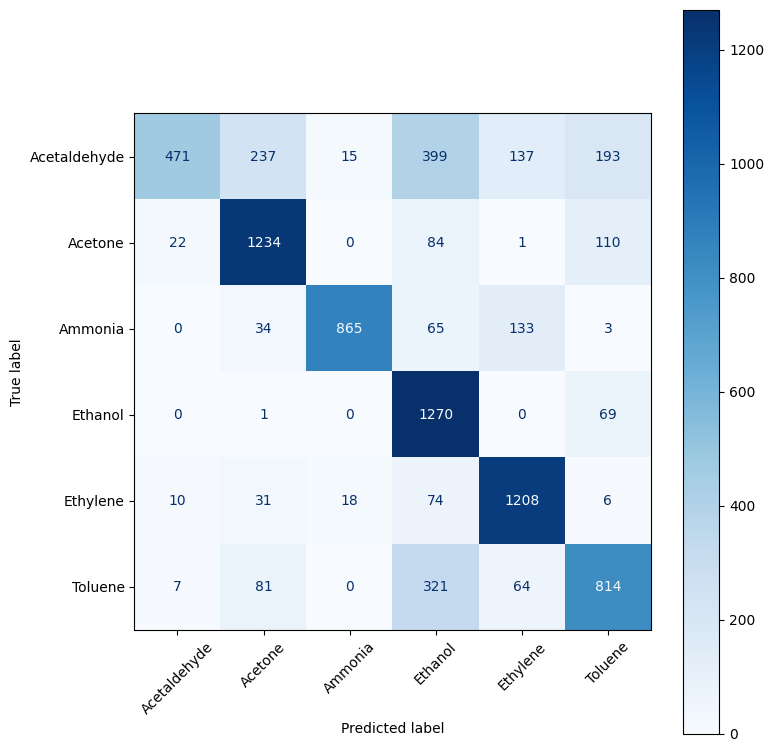

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred_final, labels=labels)

fig, ax = plt.subplots(figsize=(8,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.tight_layout()
plt.show()


In [66]:
import joblib

joblib.dump(final_model, 'final_model_svm.pkl')
joblib.dump(scaler, 'final_scaler.pkl')


['final_scaler.pkl']

In [67]:
# Final model: SVM (C=10, rbf), trained on batches [1,2,3,4], tested on remaining batches.
# Accuracy ~73%, limited by sensor drift across batches (time periods).
